In [3]:
import gensim.downloader as api
wiki_model = api.load("glove-wiki-gigaword-50")


In [5]:
# pip install gensim
wiki_model.vector_size

50

In [7]:
bank_v = wiki_model['bank']
loan_v = wiki_model['loan']
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([bank_v], [loan_v])

array([[0.67568016]], dtype=float32)

In [10]:
bank_v = wiki_model['dhoni']
loan_v = wiki_model['rahul']
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([bank_v], [loan_v])

array([[0.8356801]], dtype=float32)

In [11]:
for word, score in wiki_model.most_similar('dhoni',topn=5):
    print(word, score)

dravid 0.868076503276825
yuvraj 0.8542092442512512
ganguly 0.84922194480896
kumble 0.8360500931739807
rahul 0.8356800675392151


In [12]:
loan_v

array([-0.33427 , -0.71831 ,  0.23508 ,  0.816   ,  0.90321 ,  0.20248 ,
        1.1754  ,  0.06973 , -0.023236,  0.3165  ,  0.3398  ,  1.5831  ,
       -1.1176  ,  1.2782  , -0.22172 ,  0.33129 , -0.30211 ,  0.23153 ,
       -0.6184  , -0.13675 ,  0.24821 ,  1.6446  ,  0.19205 ,  0.084662,
        1.9944  , -0.46075 ,  0.28779 , -1.11    , -1.1892  ,  0.64099 ,
        0.31185 ,  0.31061 ,  0.38759 ,  1.6248  ,  0.73716 , -0.1432  ,
        0.48383 ,  0.45903 , -0.2289  ,  0.36481 , -0.4113  ,  1.1768  ,
        0.025607,  0.88886 , -1.0163  ,  1.3335  , -0.088277, -0.73858 ,
        0.80092 , -1.0685  ], dtype=float32)

In [13]:
words = ["loan", "credit", "finance", "money", "gold", "bank", "banana",'rahul','dhoni','virat']
word_vectors = [wiki_model[word] for word in words]

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
point_2d = pca.fit_transform(word_vectors)
point_2d[0]


array([3.11633674, 1.60263827])

In [15]:
word_vectors[0]

array([ 0.93484  ,  0.40451  ,  0.10856  , -0.61954  , -0.6922   ,
        0.32119  , -0.70885  ,  0.071233 , -0.33484  ,  0.77159  ,
       -0.050077 ,  1.1446   ,  0.01926  , -1.0259   ,  0.85535  ,
       -0.081615 ,  0.19649  , -0.051262 ,  0.40104  ,  0.87255  ,
        0.95371  , -0.87009  , -0.81569  , -0.24765  , -1.444    ,
       -0.88613  ,  1.5144   , -0.014284 , -0.48024  , -0.32289  ,
        3.0058   ,  0.49409  ,  0.72916  ,  0.60891  ,  0.59544  ,
        0.49731  , -0.0057787, -0.21278  ,  0.94938  , -2.1685   ,
        0.12593  , -0.56819  ,  0.50355  ,  0.013716 , -1.0131   ,
       -0.46806  ,  0.17305  ,  1.6204   ,  0.60405  ,  0.063104 ],
      dtype=float32)

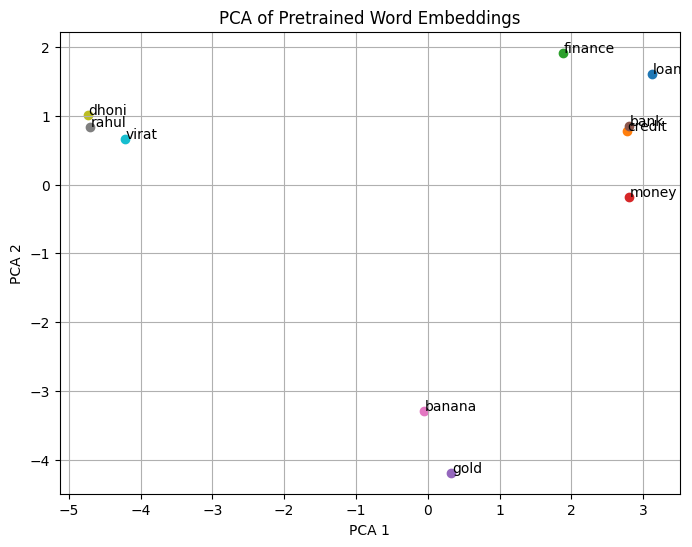

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x = point_2d[i, 0]
    y = point_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("PCA of Pretrained Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()